Outer Model: A regular stochastic volatility model

$$\frac{dS_t}{S_t} = \mu dt+\sqrt{\nu_t} dW^S_t$$

and

$$d\nu_t= \kappa(\theta-\nu_t)dt + \xi \sqrt{\nu_t} dW^\nu_t$$

with the two Wiener processes having correlation $\rho$

This is the long term effects we want to see in our model

However, let's say that we *know* there is going to be some expected vol at the beginning and end of market close.

Further, there are going to be random volatility shocks that are uncorrelated from the vol's Wiener process, likely due to significant market related effects. 

Let's upgrade the model.

First consider

$$d\nu_t= \kappa(\theta(t)-\nu_t)dt + \xi \sqrt{\nu_t} dW^\nu_t$$

Now our mean reverting vol is time dependent, which is what we want to include for market open and market close. One can calculate this by finding the average volatility of a minute time stamp across multiple days for a specific underlying.


However, we want some more sophisticated behavior to occur on short time scales, say $\tau$, i.e. $t \sim O(\varepsilon)$. More rigorously, if a shock occurs at time $t_k$, then we have
$$\tau = \frac{t - t_k}{\varepsilon}$$

Consider

$$d\nu_\tau= \alpha(\tau)d\tau + \xi \sqrt{\nu_\tau} \beta(\tau) dW^\nu_\tau$$

where
$$\alpha(\tau) = A e^{-\gamma\tau}\quad \quad \beta(\tau) = B e^{-\gamma\tau}$$



For time scales $t$ (since $d\tau =\frac{1}{\varepsilon} dt $)

$$d\nu_t = \frac{1}{\varepsilon}A e^{-\gamma\frac{t-t_k}{\varepsilon}}dt + \xi \sqrt{\nu_t}\frac{1}{\sqrt\varepsilon} Be^{-\gamma\frac{t-t_k}{\varepsilon}} dW^\nu_t$$

which is the inner component of the model


Thus, we can combine our outer and inner model:

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\frac{1}{\varepsilon}A e^{-\gamma\frac{t-t_k}{\varepsilon}})dt + \xi \sqrt{\nu_t}(1+\frac{1}{\sqrt{\varepsilon}}Be^{-\gamma\frac{t-t_k}{\varepsilon}}) dW^\nu_t$$



However, this is only for one spike. So we can generate an aribtrary number of spikes via a Poisson Process. Consider a Poisson Process $\{N_t\}_{t<\text{one day}}$ with associated jump times $\{{t_k}_i\}$. Then our model is:

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\sum_{{t_k}_i<t}[\frac{1}{\varepsilon}A e^{-\gamma\frac{t-{t_k}_i}{\varepsilon}}])dt + \xi \sqrt{\nu_t}(1+\sum_{{t_k}_i<t}[\frac{1}{\sqrt{\varepsilon}}Be^{-\gamma\frac{t-{t_k}_i}{\varepsilon}}]) dW^\nu_t$$


Finally, the contribution of the spikes can be treated as a sum of decaying Poisson processes. This provides us with:

$$dY_t = -\frac{\gamma}{\varepsilon} Y_tdt + dN_t$$

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\frac{A}{\varepsilon}Y_t)dt + \xi\sqrt{\nu_t}dW^\nu_t + \xi\sqrt{\nu_t}\frac{B}{\sqrt{\varepsilon}}Y_tdW^J_t $$

$$\frac{dS_t}{S_t} = \mu dt+\sqrt{\nu_t} dW^S_t$$


In [2]:
import numpy as np
from numba import njit

@njit
def generate_dws_dwv_dwj(dt, rho, rho_sj):
    """
    dt: time step
    rho: Correlation between (S, V) AND (J, V)
    rho_sj: Correlation between S and J
    """
    z1 = np.random.normal()
    z2 = np.random.normal()
    z3 = np.random.normal()
    
    sqrt_dt = np.sqrt(dt)

    # 1. Volatility noise (The anchor)
    dw_v = sqrt_dt * z1

    # 2. Stock noise (Correlated with V by rho)
    dw_s = sqrt_dt * (rho * z1 + np.sqrt(1 - rho**2) * z2)

    # 3. Jump noise 
    # Must have 'rho' as the z1 coefficient to maintain Corr(J, V) = rho
    # We solve for 'a' to satisfy Corr(S, J) = rho_sj
    # rho_sj = (rho * rho) + (sqrt(1-rho^2) * a)
    
    a = (rho_sj - rho**2) / np.sqrt(1 - rho**2)
    
    # Check if the correlation matrix is positive semi-definite
    # The sum of squares of coefficients must be 1
    remaining_var = 1 - rho**2 - a**2
    
    if remaining_var < 0:
        raise ValueError("Correlation parameters are inconsistent. |rho_sj| is too low/high for this rho.")
        
    b = np.sqrt(remaining_var)

    dw_j = sqrt_dt * (rho * z1 + a * z2 + b * z3)

    return dw_s, dw_v, dw_j

@njit
def simulate_full_system(
    S_inital = 100,
    T=390,           # trading minutes in a day
    dt=.1,           # 1 minute step
    eps=1E-3,        # boundary thickness
    kappa=.01,         # variance mean reversion speed
    theta=1.5e-7,    # long-run variance
    xi=3e-5,         # vol-of-vol
    gamma=1E0,      # price impact / drift adjustment
    A=5E-10,       # jump size mean
    B=2E-3,         # jump size std
    mu=.07 / (252*6.5*60),         # drift (intraday ≈ 0)
    rho=0,       # leverage effect
    rho_j = .7,
    lambda_jump= 1 / (6.5*60)  # jumps per minute (~8 per day)
):
    n_steps = int(T / dt)
    S = np.zeros(n_steps)
    nu = np.zeros(n_steps)
    Y = np.zeros(n_steps)
    r = np.zeros(n_steps)
    jump_times = np.full(n_steps, np.nan)  # nan = no jump
    t_list = np.arange(0, T, dt)
    
    S[0] = S_inital
    nu[0] = theta
    Y[0] = 0.0
    
    # Pre-calculate noise scaling constant
    # noise_const = np.sqrt(eps * B**2 / A**2) if A != 0 else 0
    
    for t in range(n_steps - 1):
        # 1. Handle Poisson Jumps for dN_t
        # Prob of jump in dt is lambda * dt
        jump = 0.0
        if np.random.random() < lambda_jump * dt or t==0 or t==t_list[-15]:
            jump = 1 
            jump_times[t] = S[t] 
            # print(f"Jump at time {t}")
            
        # 2. Update Y (The Shock Variable)
        # dY = -(gamma/eps)*Y*dt + (A/eps)*dN
        
        # 3. Generate Correlated Brownian Motion
        dw_s, dw_v, dw_j = generate_dws_dwv_dwj(dt, rho, rho_j)
                
        # Y update
        Y[t+1] = Y[t] + (-gamma * Y[t]) * dt + jump

        # variance
        v_pos = max(nu[t], 0.0)

        nu[t+1] = nu[t] + (kappa * (theta - nu[t]) + A* Y[t] / eps) * dt + xi  * np.sqrt(v_pos) * dw_v + xi *np.sqrt(v_pos) * B * Y[t] / np.sqrt(eps) *dw_j
        while nu[t+1] < 0:
            dw_s, dw_v, dw_j = generate_dws_dwv_dwj(dt, rho, rho_j)
            nu[t+1] = nu[t] + (kappa * (theta - nu[t]) + A* Y[t] / eps) * dt + xi  * np.sqrt(v_pos) * dw_v + xi *np.sqrt(v_pos) * B * Y[t] / np.sqrt(eps) *dw_j

        # price
        S[t+1] = S[t] * (1 + (mu)*dt + np.sqrt(v_pos)*dw_s)
        r[t] = (mu)*dt + np.sqrt(v_pos)*dw_s
        # print("S : ",S[t], "r : ",1-np.exp((mu - 0.5*v_pos)*dt + np.sqrt(v_pos)*dw_s), "var : ",v_pos, "walk : ",dw_s)
        
    return S, nu, Y, r, t_list, jump_times

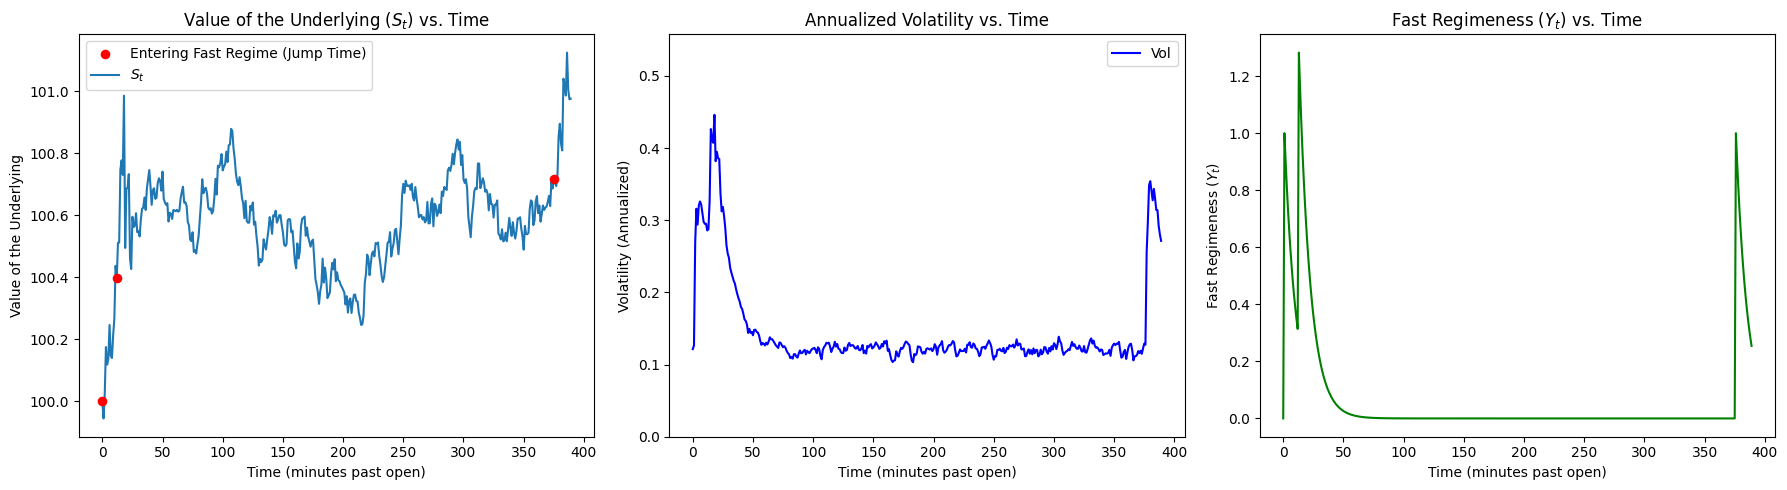

In [ ]:
import matplotlib.pyplot as plt
 
# Run your simulation
S, nu, Y, r, t, jump_times = simulate_full_system(dt=1, T=390, kappa=.3, rho=-.6, gamma=.1, B=2E-1, lambda_jump=2 / (6.5*60))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# --- First subplot: S vs t ---
axes[0].scatter(t, jump_times, s=35, c='red', label='Entering Fast Regime (Jump Time)', zorder=2)
axes[0].plot(t, S, label=r'$S_t$', zorder=1)
axes[0].set_ylabel('Value of the Underlying')
axes[0].set_xlabel('Time (minutes past open)')

axes[0].set_title(r'Value of the Underlying $(S_t)$ vs. Time')
axes[0].legend()

# --- Second subplot: nu vs t ---
axes[1].plot(t, np.sqrt(nu)*313.5,  c='blue', label='Vol')
axes[1].set_ylabel('Volatility (Annualized)')
axes[1].set_ylim(0, max(np.sqrt(nu)*313.5)*1.25)
axes[1].set_xlabel('Time (minutes past open)')

axes[1].set_title('Annualized Volatility vs. Time')
axes[1].legend()

# --- Third subplot: Y vs t ---
axes[2].plot(t, Y, c='green')
axes[2].set_xlabel('Time (minutes past open)')
axes[2].set_ylabel(r'Fast Regimeness $(Y_t)$')
axes[2].set_title(r'Fast Regimeness $(Y_t)$ vs. Time')

# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout()

# Save as a single high-quality PNG
# plt.savefig('combined_plots.png', dpi=600, bbox_inches='tight')
plt.show()

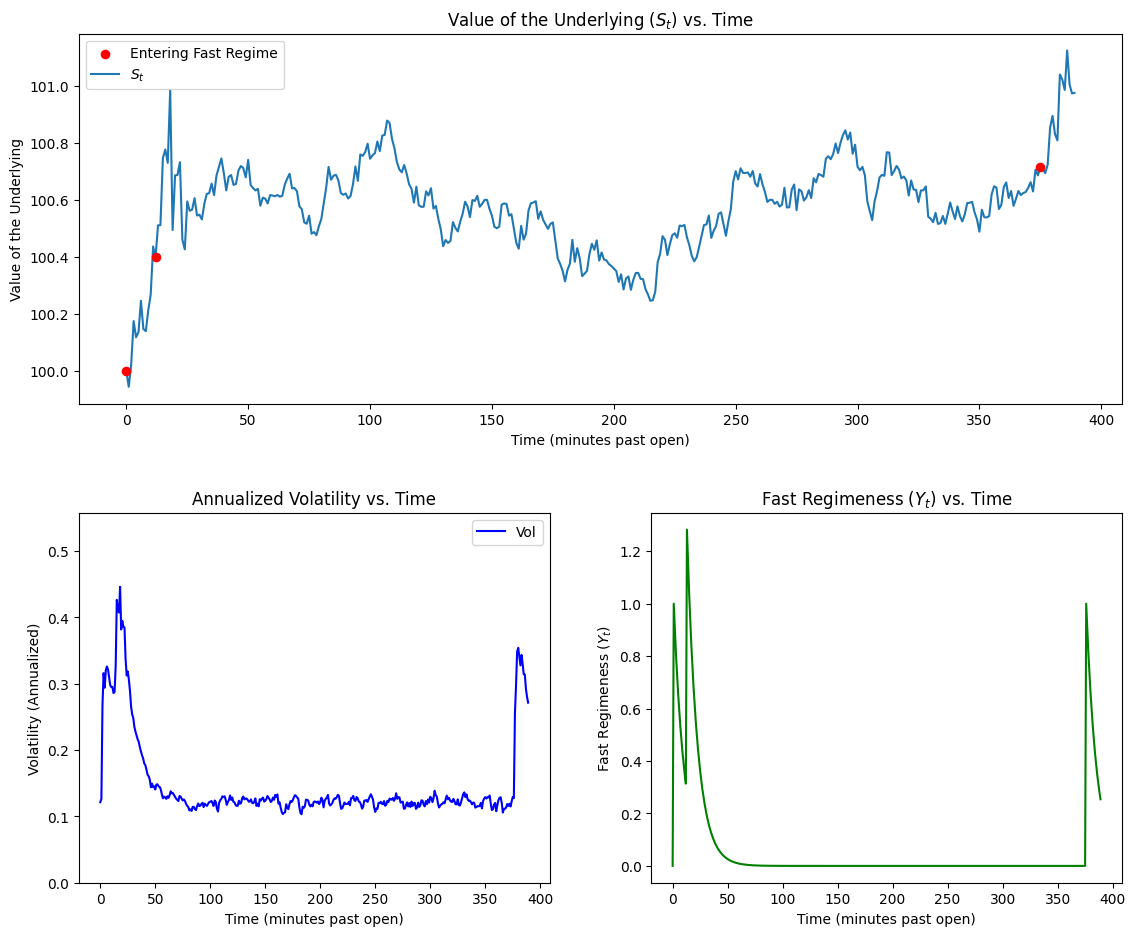

In [155]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Create a figure
fig = plt.figure(figsize=(12, 10))

# Create a 2x2 grid with specific spacing to keep it symmetric
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])

# --- Subplot 1: The Top Apex (Centered) ---
# We use a nested GridSpec or manual positioning to truly center the top one
ax0 = fig.add_subplot(gs[0, :]) # Spanning both columns for symmetry

ax0.scatter(t, jump_times, s=35, c='red', label='Entering Fast Regime', zorder=2)
ax0.plot(t, S, label=r'$S_t$', zorder=1)
ax0.set_ylabel('Value of the Underlying')
ax0.set_title(r'Value of the Underlying $(S_t)$ vs. Time')
ax0.set_xlabel('Time (minutes past open)')

ax0.legend()

# --- Subplot 2: Bottom Left ---
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(t, np.sqrt(nu)*313.5,  c='blue', label='Vol')
ax1.set_ylabel('Volatility (Annualized)')
ax1.set_ylim(0, max(np.sqrt(nu)*313.5)*1.25)
ax1.set_xlabel('Time (minutes past open)')
ax1.set_title('Annualized Volatility vs. Time')
ax1.legend()

# --- Subplot 3: Bottom Right ---
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(t, Y, c='green')
ax2.set_xlabel('Time (minutes past open)')
ax2.set_ylabel(r'Fast Regimeness $(Y_t)$')
ax2.set_title(r'Fast Regimeness $(Y_t)$ vs. Time')

# Aesthetic adjustments
plt.tight_layout(pad=3.0)
plt.savefig('trefoil_plots.png', dpi=600, bbox_inches='tight')
plt.show()

In [156]:
from tqdm import tqdm
final_vals = np.zeros(100000)
final_var = np.zeros(100000)
for i in tqdm(range(100000)):
    j = simulate_full_system(dt=1, T=390, kappa=.3, gamma=.1, B=2E-1, rho=-.6, lambda_jump=2 / (6.5*60))
    final_vals[i] = j[0][-1]
    final_var[i] = j[1][-1]

100%|██████████| 100000/100000 [00:04<00:00, 20949.52it/s]


In [211]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Parameters
n_sims = 100000
T = 390
dt = 1
n_steps = int(T / dt) 

# Pre-allocate 2D arrays for speed
all_prices = np.zeros((n_sims, n_steps))
all_vols = np.zeros((n_sims, n_steps))

print("Running 100,000 Simulations...")
for i in tqdm(range(n_sims)):
    # Assuming S_path and nu_path are the first two returned values
    S_path, nu_path, _,_,_,_= simulate_full_system(dt=dt, T=T, kappa=.3, mu = .5/(252*6.5*60) ,gamma=.1, B=2E-1, lambda_jump=2 / (6.5*60))
    all_prices[i, :] = S_path
    all_vols[i, :] = nu_path

# --- Efficient Data Squeezing ---

# 1. Flatten all volatility points and annualize
# Scaling by sqrt(252 * 6.5 * 60 / dt) approx 313.5 for minutely data
squeezed_vol = np.sqrt(all_vols.flatten()) * 313.5

# 2. Calculate Log Returns per simulation, then flatten
# log(S_t) - log(S_{t-1})
log_returns_matrix = np.diff(np.log(all_prices), axis=1)
squeezed_log_returns = log_returns_matrix.flatten()

Running 100,000 Simulations...


100%|██████████| 100000/100000 [00:05<00:00, 19145.25it/s]


<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/var/folders/80/yg22fq6568d_n43d51ww65kr0000gn/T/ipykernel_41681/1286274454.py:19: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_xlabel('Annualized Volatility ($\sigma_{ann}$)')


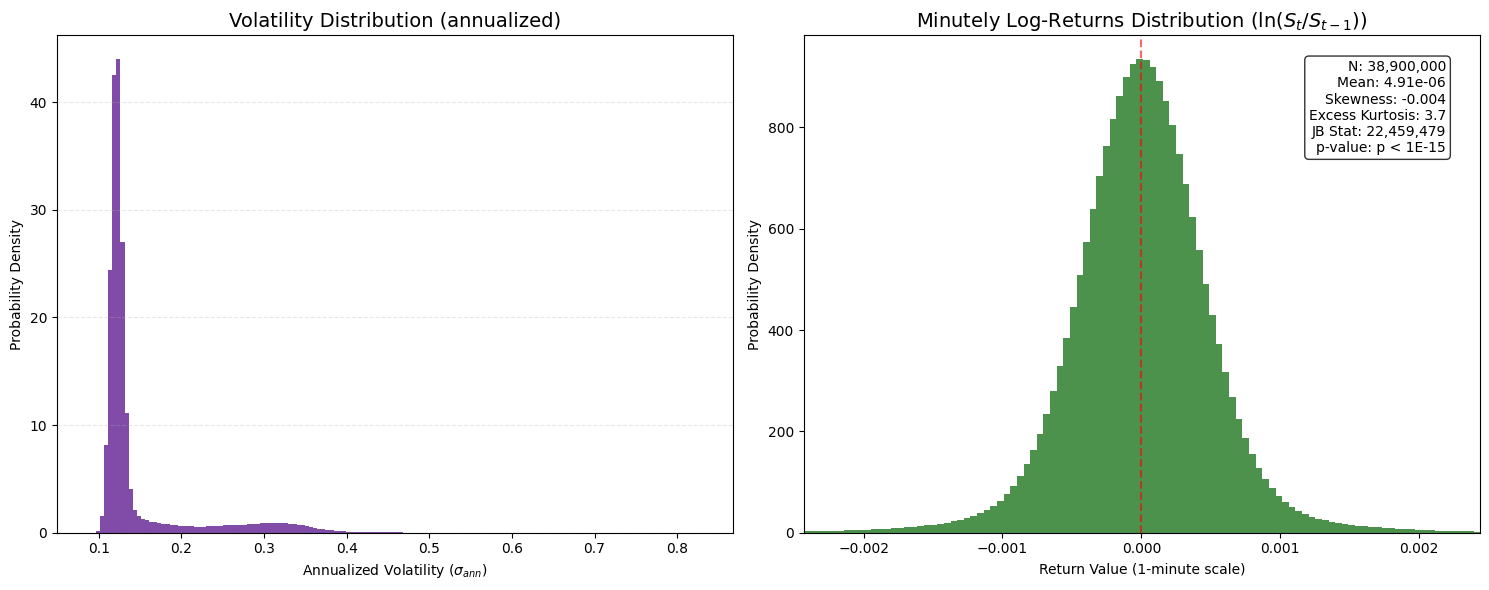

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew, jarque_bera

# --- Stats Calculation ---
# Note: sample_size reflects the total observations across all sims
sample_size = len(squeezed_log_returns)
jb_stat, p_value = jarque_bera(squeezed_log_returns)
excess_kurt = kurtosis(squeezed_log_returns)
log_skew = skew(squeezed_log_returns)
mean_return = np.mean(squeezed_log_returns)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Annualized Volatility Distribution
axes[0].hist(squeezed_vol, bins=150, color='indigo', alpha=0.7, density=True)
axes[0].set_title('Volatility Distribution (annualized)', fontsize=14)
axes[0].set_xlabel('Annualized Volatility ($\sigma_{ann}$)')
axes[0].set_ylabel('Probability Density')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Right: Minutely Log-Returns Distribution
axes[1].hist(squeezed_log_returns, bins=300, color='darkgreen', alpha=0.7, density=True)
axes[1].set_title(r'Minutely Log-Returns Distribution ($\ln(S_t/S_{t-1})$)', fontsize=14)
axes[1].set_xlabel('Return Value (1-minute scale)')
axes[1].set_ylabel('Probability Density')

# Add vertical reference line at 0
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6, label='Zero Return')

# Text Box with Stats
# Create a cleaner p-value string
if p_value < 1E-15:
    p_string = "p < 1E-15"
else:
    p_string = f"p = {p_value:.4e}"

# Updated Statistical Text Box for the plot
stats_label = (
    f'N: {sample_size:,}\n'
    f'Mean: {mean_return:.2e}\n'
    f'Skewness: {log_skew:.3f}\n'
    f'Excess Kurtosis: {excess_kurt:.1f}\n'
    f'JB Stat: {jb_stat:,.0f}\n'
    f'p-value: {p_string}' # Uses the new string
)

axes[1].text(0.95, 0.95, stats_label, transform=axes[1].transAxes, 
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Robustly handle jump outliers for visualization clarity
r_min, r_max = np.percentile(squeezed_log_returns, [0.1, 99.9])
axes[1].set_xlim(r_min, r_max)

plt.tight_layout()
plt.savefig('minutely_distribution_results.png', dpi=600, bbox_inches='tight')
plt.show()

In [159]:
from scipy.stats import kurtosis, skew

# Calculate Excess Kurtosis (Fisher’s definition: Normal = 0)
excess_kurt = kurtosis(squeezed_log_returns)
# Calculate Skewness (Symmetry: Normal = 0)
log_skew = skew(squeezed_log_returns)

print(f"Excess Kurtosis: {excess_kurt:.4f}")
print(f"Skewness: {log_skew:.4f}")

Excess Kurtosis: 3.4815
Skewness: -0.0030


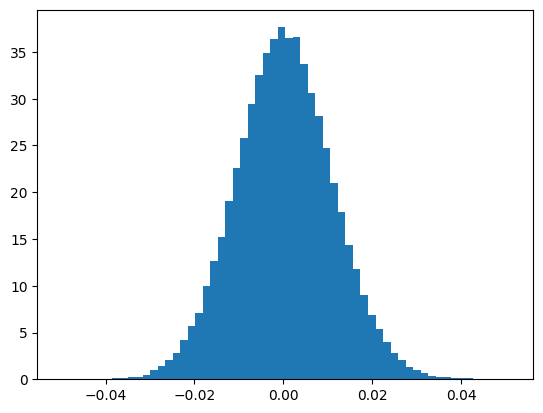

In [160]:
plt.hist(final_vals/100-1, density = True, bins = 60)
plt.show()

100%|██████████| 1000000/1000000 [00:47<00:00, 20971.74it/s]


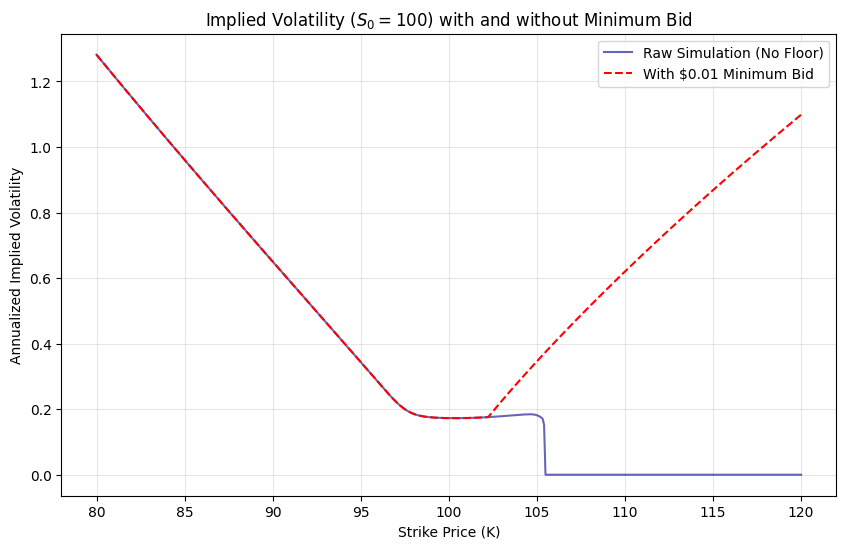

In [194]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# --- Black-Scholes for Inversion ---
def bs_call(S, K, T_years, r, sigma):
    if sigma <= 0: return max(0, S - K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T_years) / (sigma * np.sqrt(T_years))
    d2 = d1 - sigma * np.sqrt(T_years)
    return S * norm.cdf(d1) - K * np.exp(-r * T_years) * norm.cdf(d2)

def find_iv(target_price, S, K, T_years, r):
    # Solves for sigma where BS_Price - Simulated_Price = 0
    if target_price <= max(0, S - K * np.exp(-r * T_years)): return 0.0
    obj = lambda sigma: bs_call(S, K, T_years, r, sigma) - target_price
    try:
        return brentq(obj, 1e-6, 5.0)
    except:
        return np.nan

# --- Running the IV Simulation ---
n_paths = 1000000  # Number of paths to average out the jump noise
S_initial = 100
T_minutes = 390
T_years = T_minutes / (252 * 6.5 * 60) # Convert your T to annual for BS
r = 0.05 / (252*6.5*60)

# 1. Generate final prices from your model
# --- 1. Generate final prices once ---
final_prices = []
for _ in tqdm(range(n_paths)):
    # Adjusting based on your unpack sequence
    S_path, _, _, _, _, _ = simulate_full_system(dt=1, T=T, kappa=.3, gamma=.1, B=2E-1, rho=-.7, lambda_jump=2 / (6.5*60))
    final_prices.append(S_path[-1])
final_prices = np.array(final_prices)

# --- 2. Define Strike Range ---
strikes = np.linspace(S_initial * 0.8, S_initial * 1.2, 500)
iv_no_floor = []
iv_with_floor = []

scaling_factor = np.sqrt(252 * 6.5 * 60) # To annualize your minute-based IV

for K in strikes:
    # Pure Monte Carlo Price
    raw_mkt_price = np.exp(-r * T_minutes) * np.mean(np.maximum(final_prices - K, 0))
    
    # Floor Price at 0.01
    floored_mkt_price = np.maximum(raw_mkt_price, 0.01)
    
    # Calculate IVs
    iv_no_floor.append(find_iv(raw_mkt_price, S_initial, K, T_minutes, r))
    iv_with_floor.append(find_iv(floored_mkt_price, S_initial, K, T_minutes, r))

# --- 3. Plotting ---
plt.figure(figsize=(10, 6))

# Curve 1: Raw Simulation
plt.plot(strikes, [i * scaling_factor for i in iv_no_floor], 
         label='Raw Simulation (No Floor)', color='darkblue', alpha=0.6)

# Curve 2: With $0.01 Minimum Bid
plt.plot(strikes, [i * scaling_factor for i in iv_with_floor], 
         label='With $0.01 Minimum Bid', color='red', linestyle='--')

plt.title(r'Implied Volatility $(S_0 = 100)$ with and without Minimum Bid')
plt.xlabel('Strike Price (K)')
plt.ylabel('Annualized Implied Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Plot saved as iv_smile_comparison.png


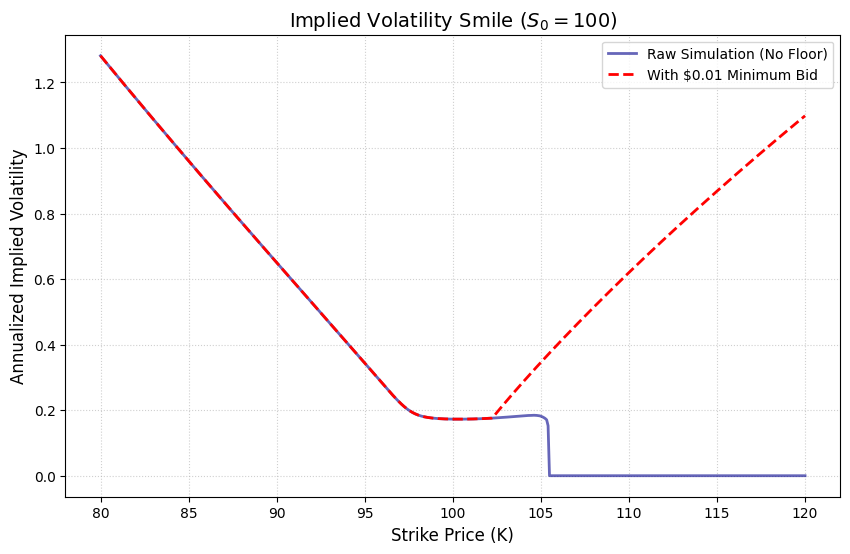

In [195]:
# --- 3. Plotting & Saving ---
plt.figure(figsize=(10, 6))

# Annualized scaling is already handled by feeding annualized T to the solver
# But if find_iv used minutes, the scaling_factor approach works too.
plt.plot(strikes, [i * scaling_factor for i in iv_no_floor], 
         label='Raw Simulation (No Floor)', color='darkblue', alpha=0.6, linewidth=2)

plt.plot(strikes, [i * scaling_factor for i in iv_with_floor], 
         label='With $0.01 Minimum Bid', color='red', linestyle='--', linewidth=2)

# Styling for LaTeX
plt.title(r'Implied Volatility Smile ($S_0 = 100$)', fontsize=14)
plt.xlabel('Strike Price (K)', fontsize=12)
plt.ylabel('Annualized Implied Volatility', fontsize=12)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Save high-res for LaTeX
plt.savefig('iv_smile_comparison.png', dpi=600, bbox_inches='tight')
print("Plot saved as iv_smile_comparison.png")

plt.show()

Running Monte Carlo simulation (this will take a moment)...

--- Results ---
Custom Model ATM Call Price: $0.0728
Black-Scholes ATM Implied Vol: 0.04%


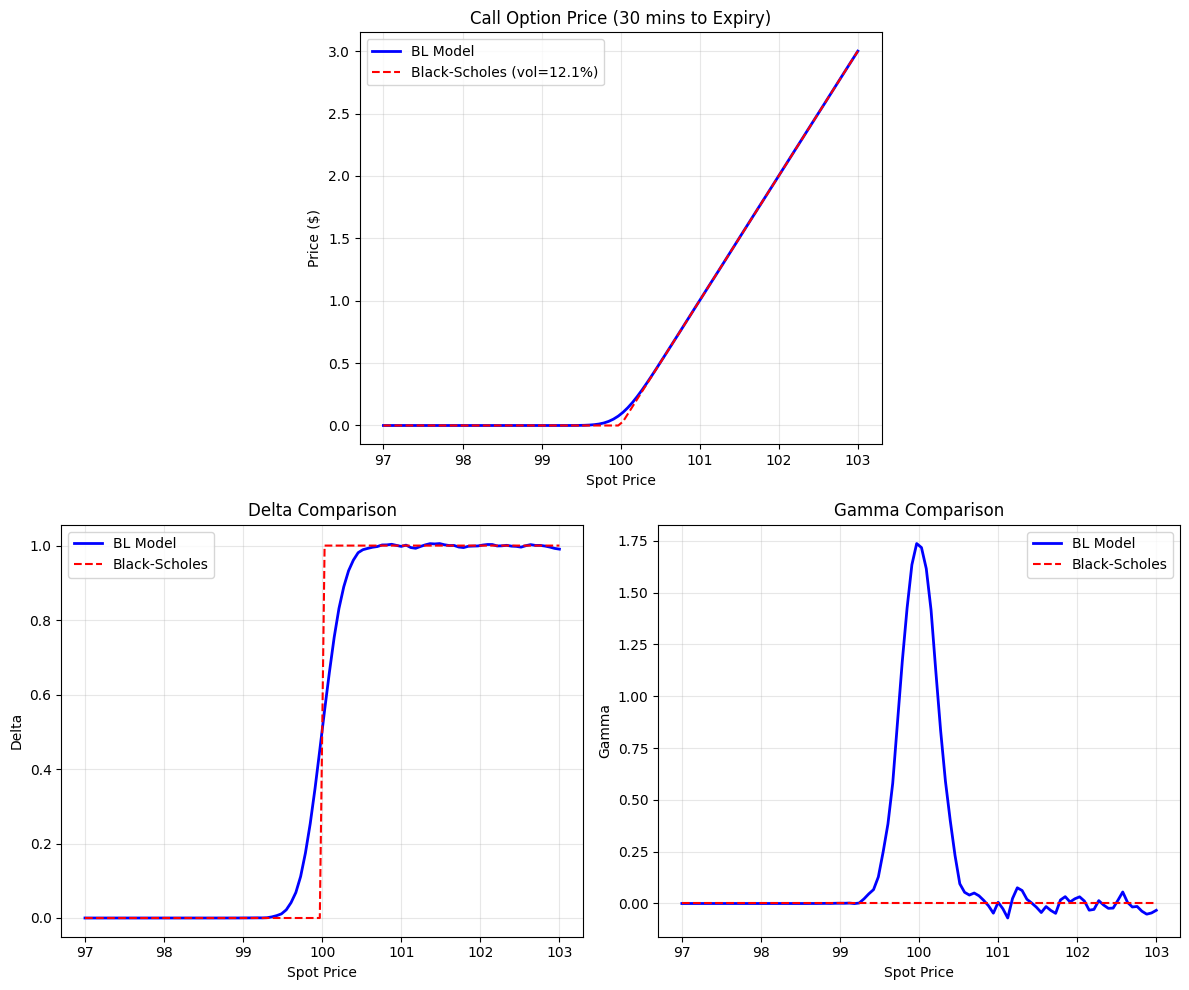

In [210]:
from numba import prange, njit
import numpy as np
import scipy.stats as si
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# [Keep your existing generate_dws_dwv_dwj and simulate_full_system functions here]

# ---------------------------------------------------------
# 1. Monte Carlo Pricer Wrapper
# ---------------------------------------------------------
@njit(parallel=True)
def price_options_mc(spots, K=100.0, T_min=30.0, dt=0.1, num_paths=100000):
    prices = np.zeros(len(spots))
    for i in prange(len(spots)):
        S0 = spots[i]
        payoff_sum = 0.0
        for _ in range(num_paths):
            S, _, _, _, _, _ = simulate_full_system(S_inital=S0, T=T_min, dt=dt)
            payoff_sum += max(S[-1] - K, 0.0)
        prices[i] = payoff_sum / num_paths
    return prices

# ---------------------------------------------------------
# Black-Scholes Utility Functions
# ---------------------------------------------------------
def bs_price(S, K, T, r, sigma):
    """Standard Black-Scholes European Call Price"""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)

def get_implied_vol(target_price, S, K, T, r):
    """Find implied volatility using Brent's method"""
    def obj_func(sigma): 
        return bs_price(S, K, T, r, sigma) - target_price
    try:
        return brentq(obj_func, 1e-4, 5.0)
    except ValueError:
        return np.nan

def bs_greeks(S, K, T, r, sigma):
    """Standard Black-Scholes Delta and Gamma"""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    delta = si.norm.cdf(d1)
    gamma = si.norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return delta, gamma

# ---------------------------------------------------------
# Execution & Analysis
# ---------------------------------------------------------
K = 100.0
T_min = 30.0
dt = 0.1
spots = np.linspace(97, 103, 100) 

min_per_year = 252 * 6.5 * 60  
T_years = T_min / min_per_year
r = 0.05  

print("Running Monte Carlo simulation (this will take a moment)...")
raw_mc_prices = price_options_mc(spots, K=K, T_min=T_min, dt=dt, num_paths=50000)
mc_prices = raw_mc_prices * np.exp(-r * T_years)  

# Fit a polynomial to smooth out MC noise
from scipy.signal import savgol_filter

# window_length must be odd, polyorder is usually 2 or 3
smoothed_mc_prices = savgol_filter(mc_prices, window_length=11, polyorder=3)

# Then use finite differences as you were before
dS = spots[1] - spots[0]
custom_delta = np.gradient(smoothed_mc_prices, dS)
custom_gamma = np.gradient(custom_delta, dS)

# 2. Extract ATM Implied Volatility
atm_index = np.argmin(np.abs(spots - 100.0))
atm_price = mc_prices[atm_index]
# atm_iv = get_implied_vol(atm_price, 100.0, K, T_years, r)
atm_iv = np.sqrt(1.5E-7)

print(f"\n--- Results ---")
print(f"Custom Model ATM Call Price: ${atm_price:.4f}")
print(f"Black-Scholes ATM Implied Vol: {atm_iv:.2%}")

# 3. Calculate Black-Scholes Prices and Greeks
bs_prices = np.array([bs_price(S, K, T_years, r, atm_iv) for S in spots])
bs_delta, bs_gamma = bs_greeks(spots, K, T_years, r, atm_iv)

# 4. Plotting in a Trefoil Layout
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 4, figure=fig)

# Top Center: Price Plot
ax_price = fig.add_subplot(gs[0, 1:3])
ax_price.plot(spots, smoothed_mc_prices, label='BL Model', color='blue', lw=2)
ax_price.plot(spots, bs_prices, label=f'Black-Scholes (vol={atm_iv *np.sqrt(252*6.5*60):.1%})', color='red', linestyle='--')
ax_price.set_title("Call Option Price (30 mins to Expiry)")
ax_price.set_xlabel("Spot Price")
ax_price.set_ylabel("Price ($)")
ax_price.grid(True, alpha=0.3)
ax_price.legend()

# Bottom Left: Delta Plot
ax_delta = fig.add_subplot(gs[1, 0:2])
ax_delta.plot(spots, custom_delta, label='BL Model', color='blue', lw=2)
ax_delta.plot(spots, bs_delta, label='Black-Scholes', color='red', linestyle='--')
ax_delta.set_title("Delta Comparison")
ax_delta.set_xlabel("Spot Price")
ax_delta.set_ylabel("Delta")
ax_delta.grid(True, alpha=0.3)
ax_delta.legend()

# Bottom Right: Gamma Plot
ax_gamma = fig.add_subplot(gs[1, 2:4])
ax_gamma.plot(spots, custom_gamma, label='BL Model', color='blue', lw=2)
ax_gamma.plot(spots, bs_gamma, label='Black-Scholes', color='red', linestyle='--')
ax_gamma.set_title("Gamma Comparison")
ax_gamma.set_xlabel("Spot Price")
ax_gamma.set_ylabel("Gamma")
ax_gamma.grid(True, alpha=0.3)
ax_gamma.legend()

plt.tight_layout()
plt.savefig('greeks_comparison_results.png', dpi=600, bbox_inches='tight')
plt.show()

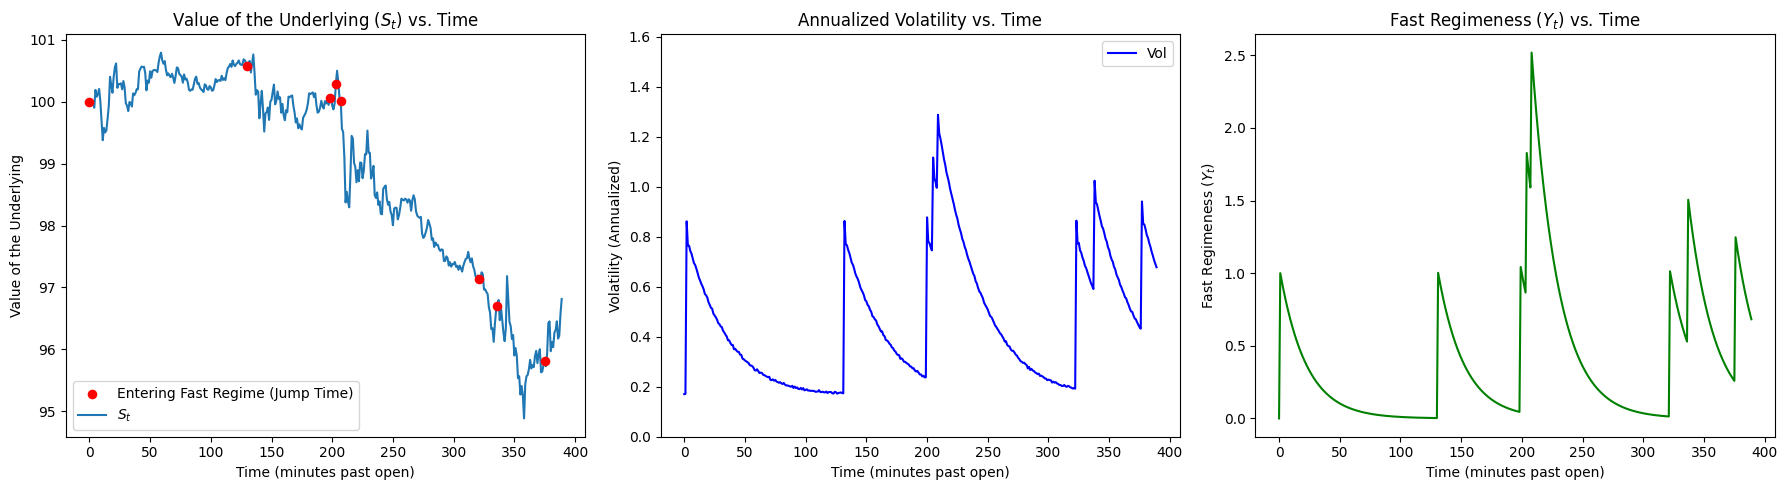

In [11]:
import matplotlib.pyplot as plt

minute_cont = 252*6.5*60
# Run your simulation
S, nu, Y, r, t, jump_times = simulate_full_system(dt=1, T=390, kappa=367/np.sqrt(minute_cont), rho=-.6, xi = 1.634/minute_cont, theta = .029/minute_cont, gamma=.0453, A=7.2E-6/minute_cont, B=5.2E-2/minute_cont, eps=1.01E-5, lambda_jump=4 / (6.5*60))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# --- First subplot: S vs t ---
axes[0].scatter(t, jump_times, s=35, c='red', label='Entering Fast Regime (Jump Time)', zorder=2)
axes[0].plot(t, S, label=r'$S_t$', zorder=1)
axes[0].set_ylabel('Value of the Underlying')
axes[0].set_xlabel('Time (minutes past open)')

axes[0].set_title(r'Value of the Underlying $(S_t)$ vs. Time')
axes[0].legend()

# --- Second subplot: nu vs t ---
axes[1].plot(t, np.sqrt(nu)*313.5,  c='blue', label='Vol')
axes[1].set_ylabel('Volatility (Annualized)')
axes[1].set_ylim(0, max(np.sqrt(nu)*313.5)*1.25)
axes[1].set_xlabel('Time (minutes past open)')

axes[1].set_title('Annualized Volatility vs. Time')
axes[1].legend()

# --- Third subplot: Y vs t ---
axes[2].plot(t, Y, c='green')
axes[2].set_xlabel('Time (minutes past open)')
axes[2].set_ylabel(r'Fast Regimeness $(Y_t)$')
axes[2].set_title(r'Fast Regimeness $(Y_t)$ vs. Time')

# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout()

# Save as a single high-quality PNG
# plt.savefig('combined_plots.png', dpi=600, bbox_inches='tight')
plt.show()